# Iterative sample-based ridge regularization (self-contained)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import norm

## Covariance matrix generators

In [2]:
def bulk(D):
    """
    Bulk-type covariance eigenvalues

    Args:
        D: the number of parameters in the data matrix

    Returns:
        Sigma: the covariance matrix
    """
    j = np.arange(1, D + 1)
    eigenvalues = (D - j + 1) / D
    Sigma = np.diag(eigenvalues)
    return Sigma


def spiked(D):
    """
    Spiked-type covariance eigenvalues.

    Args:
        D: the number of parameters in the data matrix

    Returns:
        Sigma: the covariance matrix
    """
    x = np.linspace(-3, 3, D)
    eigenvalues = norm.pdf(x)
    eigenvalues = eigenvalues / eigenvalues.max()
    Sigma = np.diag(eigenvalues)
    return Sigma

## Data generation (from alg1.py)

In [3]:
def GenXData(N, D, Sigma):
    """
    Generates a random mean-centered X from a multivariate normal distribution.

    Args:
        N: the number of observations.
        D: the number of parameters.
        Sigma: the covariance matrix of the data matrix
            X with shape DxD.

    Returns:
        A matrix X of the shape NxD (N rows, D columns).
    """
    rng = np.random.default_rng(seed=77)
    mu = np.zeros(D)
    X = rng.multivariate_normal(mean=mu, cov=Sigma, size=N)
    return X - X.mean(axis=0)


def GenYData(X, N, theta, epsilon):
    """
    Generates a random mean-centered y from a standard normal distribution.

    Args:
        X: the data matrix with shape NxD.
        N: the number of observations.
        theta: the true parameter vector.
        epsilon: the noise amplitude.

    Returns:
        A column vector y of the shape Nx1 (N rows, 1 column).
    """
    rng = np.random.default_rng(seed=77)
    z = (rng.standard_normal(size=N))[:, np.newaxis]
    y = X @ theta + epsilon * z
    return y - y.mean(axis=0)

## Useful functions (from alg2.py)

In [4]:
def H(S, V, theta, lambda_):
    """
    Calculates the H of the given lambda where H(lambda) is
        related to lambda by a factor of amplitude squared.

    Args:
        S: the singular value matrix of X from its SVD decomposition,
            with singular values on the main diagonal.
        V: the matrix of right eigenvectors of X from its SVD decomposition.
        theta: the true parameter vector.
        lambda_: the ridge regression parameter.

    Returns:
        The value of H(lambda) as a constant.
    """
    min_D_N = min(S.shape)
    sigma = np.diag(S)[:min_D_N]
    projections = (V[:, :min_D_N].T @ theta).ravel()
    top = np.sum((sigma ** 4) / (sigma ** 2 + lambda_) ** 3)
    bottom = np.sum((sigma ** 4) * (projections ** 2) / (sigma ** 2 + lambda_) ** 3)
    return top / bottom


def mse(S, V, theta, lambda_, epsilon):
    """
    Calculates the mean squared error of the given parameters, in particular lambda.

    Args:
        S: the singular value matrix of X from its SVD decomposition,
            with singular values on the main diagonal.
        V: the matrix of right eigenvectors of X from its SVD decomposition.
        theta: the true parameter vector.
        lambda_: the ridge regression parameter.
        epsilon: the noise amplitude.

    Returns:
        The expected out-of-sample mean squared error as a constant.
    """
    min_D_N = min(S.shape)
    sigma = np.diag(S)[:min_D_N]
    projections = (V[:, :min_D_N].T @ theta).ravel()
    bias_squared = np.sum((lambda_ * sigma * projections / (sigma ** 2 + lambda_)) ** 2)
    variance = (epsilon ** 2) * np.sum(((sigma ** 2) / (sigma ** 2 + lambda_)) ** 2)
    return (1 / S.shape[0]) * (bias_squared + variance) + (epsilon ** 2)


def ModelOptReg(S, V, theta, epsilon, lambda_0, delta):
    """
    Calculates the optimal ridge regression parameter through a fixed-point method.

    Args:
        S: the singular value matrix of X from its SVD decomposition,
            with singular values on the main diagonal.
        V: the matrix of right eigenvectors of X from its SVD decomposition.
        theta: the true parameter vector.
        epsilon: the noise amplitude.
        lambda_0: the initial ridge regression parameter, often set to 1.
        delta: the iteration step size from lambda to lambda, often set to 10^{-4}.

    Returns:
        The optimal lambda and its corresponding MSE value as a tuple.
    """
    lambda_ = lambda_0
    lambda_p = lambda_0 + 2 * delta
    while np.abs(lambda_ - lambda_p) > delta:
        lambda_p = lambda_
        lambda_ = (epsilon ** 2) * H(S, V, theta, lambda_)
    return lambda_, mse(S, V, theta, lambda_, epsilon)

## Noise estimation (from alg3.py)

In [5]:
def EpsilonEstimate(X, U, S, V, y, p, lambda_0):
    """
    Calculates the estimate of the noise amplitude
        in the overparameterized and underparameterized case.

    Args:
        X: the design matrix with shape NxD.
        U: the matrix of left eigenvectors of X from its SVD decomposition.
        S: the singular value matrix of X from its SVD decomposition,
            with singular values on the main diagonal.
        V: the matrix of right eigenvectors of X from its SVD decomposition.
        y: the truth vector with shape Nx1.
        p: the exponent parameter for the regularized rank.
        lambda_0: the initial ridge regression parameter, often set to 1.

    Returns:
        The estimate of the noise amplitude as a constant.
    """
    N, D = S.shape
    min_D_N = min(N, D)
    sigma = np.diag(S)[:min_D_N]
    r_p = np.sum(((sigma ** 2) / (sigma ** 2 + lambda_0)) ** p)

    if N > D:
        theta_hat = V[:, :min_D_N] @ ((sigma / (sigma**2 + lambda_0))[:, np.newaxis] * (U[:, :min_D_N].T @ y))
        y_hat = X @ theta_hat
        epsilon_hat = np.sqrt((1/(N-1) * np.sum((y_hat - y) ** 2)) / (1 - r_p/N))
    else:
        h = N // 2
        X1, y1 = X[:h], y[:h]
        X2, y2 = X[h:], y[h:]

        U1, s1, Vt1 = np.linalg.svd(X1, full_matrices=False)
        V1 = Vt1.T
        N1, D1 = X1.shape
        min_D_N_1 = min(N1, D1)
        theta1 = V1[:, :min_D_N_1] @ ((s1 / (s1**2 + lambda_0))[:, np.newaxis] * (U1[:, :min_D_N_1].T @ y1))
        y_hat2 = X2 @ theta1

        U2, s2, Vt2 = np.linalg.svd(X2, full_matrices=False)
        V2 = Vt2.T
        N2, D2 = X2.shape
        min_D_N_2 = min(N2, D2)
        theta2 = V2[:, :min_D_N_2] @ ((s2 / (s2**2 + lambda_0))[:, np.newaxis] * (U2[:, :min_D_N_2].T @ y2))
        y_hat1 = X1 @ theta2

        mse_oos = (1/N) * (np.sum((y_hat2 - y2) ** 2) + np.sum((y_hat1 - y1) ** 2))
        epsilon_hat = np.sqrt((N/(N-1) * mse_oos) / (1 - r_p/N))

    return epsilon_hat

## Setup

In [6]:
rng = np.random.default_rng(seed=77)

EPSILON = 0.1
N_TRIAL = 1000  # number of observations N
ASPECT_RATIO = 0.3  # aspect ratio (d/N)
D_TRIAL = int(ASPECT_RATIO * N_TRIAL)  # number of parameters D

theta = rng.standard_normal(size=D_TRIAL)[:, np.newaxis]
theta = theta / np.linalg.norm(theta)

Sigma_bulk = bulk(D_TRIAL)
Sigma_spiked = spiked(D_TRIAL)

LAMBDA_0 = 1
DELTA = 10 ** -4
P = 1 / 4

## Iterative sample-based procedure

In [7]:
def IterativeSampleOptReg(Sigma, lambda_0, p, delta, theta_true, epsilon_true,
                           N_TRIAL, D_TRIAL, max_iter=100, verbose=True):
    """
    Runs the iterative sample-based optimal ridge regularization procedure
    for max_iter iterations, tracking lambda, mse,
    and epsilon_hat at every step so convergence behavior can be inspected.

    If theta_true and epsilon_true are provided, also computes the oracle
    lambda/mse (using ModelOptReg fed the true theta and epsilon) internally,
    reusing the same S, V computed from X.

    Args:
        Sigma: the covariance matrix.
        lambda_0: the initial ridge regression parameter, often set to 1.
        p: the exponent parameter for the regularized rank, used in EpsilonEstimate.
        delta: the convergence tolerance on lambda, used for the inner (ModelOptReg) loop.
        theta_true: the true parameter vector, used to compute the oracle.
        epsilon_true: the true noise amplitude, used to compute the oracle.
        N_TRIAL: number of observations.
        D_TRIAL: number of parameters.
        max_iter: number of outer iterations to run. Empirically, iteration 1
            is closest to the oracle; larger values let the estimate drift
            away before stabilizing at a worse fixed point (see notebook note).
        verbose: if True, shows a tqdm progress bar.

    Returns:
        (lambda_star, mse_star): lambda and mse from the final iteration.
        (lambdas, mses, noises): lists tracking lambda, mse, and epsilon_hat
            across every outer iteration, in order.
        (lambda_oracle, mse_oracle): the oracle lambda/mse.
    """
    X = GenXData(N_TRIAL, D_TRIAL, Sigma)
    y = GenYData(X, N_TRIAL, theta_true, epsilon_true)  # fixed: use parameters, not globals

    U, sigma, Vt = np.linalg.svd(X, full_matrices=True)
    N, D = X.shape
    V = Vt.T
    min_D_N = min(N, D)

    S = np.zeros((N, D))
    S[:min_D_N, :min_D_N] = np.diag(sigma[:min_D_N])

    lam = lambda_0
    theta_hat = V[:, :min_D_N] @ ((sigma[:min_D_N] / (sigma[:min_D_N]**2 + lambda_0))[:, np.newaxis] * (U[:, :min_D_N].T @ y))
    epsilon_hat = EpsilonEstimate(X, U, S, V, y, p, lambda_0)

    lambdas, mses, noises = [], [], []

    lambda_oracle, mse_oracle = ModelOptReg(S, V, theta_true, epsilon_true, lambda_0, delta)

    pbar = tqdm(range(max_iter), disable=not verbose, desc="IterativeSampleOptReg")
    for _ in pbar:
        lam, _ = ModelOptReg(S, V, theta_hat, epsilon_hat, lam, delta)
        mse_curr = mse(S, V, theta_true, lam, epsilon_true)  # TRUE MSE (real theta/epsilon)

        theta_hat = V[:, :min_D_N] @ ((sigma[:min_D_N] / (sigma[:min_D_N]**2 + lam))[:, np.newaxis] * (U[:, :min_D_N].T @ y))
        epsilon_hat = EpsilonEstimate(X, U, S, V, y, p, lam)

        lambdas.append(lam)
        mses.append(mse_curr)
        noises.append(epsilon_hat)

        pbar.set_postfix(lam=f"{lam:.6g}", mse=f"{mse_curr:.6g}", eps=f"{epsilon_hat:.6g}")
    pbar.close()

    return (lam, mses[-1]), (lambdas, mses, noises), (lambda_oracle, mse_oracle)

## Single run (set max_iter explicitly to see the drift over more steps)

In [8]:
(lam_star, mse_star), (lambdas, mses, noises), (lam_oracle, mse_oracle) = IterativeSampleOptReg(
    Sigma_bulk, LAMBDA_0, P, DELTA, theta_true=theta, epsilon_true=EPSILON,
    N_TRIAL=N_TRIAL, D_TRIAL=D_TRIAL, max_iter=10
)

IterativeSampleOptReg: 100%|██████████| 10/10 [00:00<00:00, 250.13it/s, eps=0.0994977, lam=4.25172, mse=0.0129132]


In [9]:
print(f"Oracle:       lambda={lam_oracle:.6g}, mse={mse_oracle:.6g}")
print(f"Sample-based: lambda={lam_star:.6g}, mse={mse_star:.6g}  (after {len(mses)} iters)")

Oracle:       lambda=4.0803, mse=0.0129131
Sample-based: lambda=4.25172, mse=0.0129132  (after 10 iters)


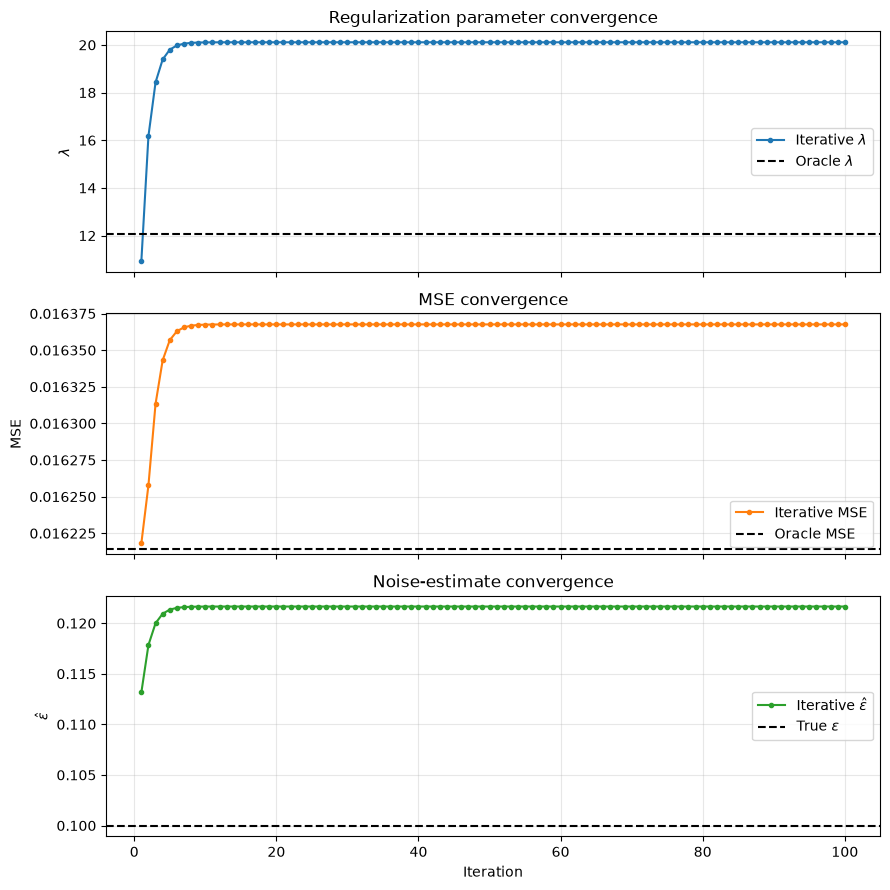

In [13]:
iterations = np.arange(1, len(lambdas) + 1)
marker_size = 3

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(iterations, lambdas, marker="o", ms=marker_size, color="tab:blue", label=r"Iterative $\lambda$")
axes[0].axhline(lam_oracle, color="black", linestyle="--", linewidth=1.5, label=r"Oracle $\lambda$")
axes[0].set_ylabel(r"$\lambda$")
axes[0].set_title(r"Regularization parameter convergence")
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].ticklabel_format(axis="y", style="plain", useOffset=False)

axes[1].plot(iterations, mses, marker="o", ms=marker_size, color="tab:orange", label="Iterative MSE")
axes[1].axhline(mse_oracle, color="black", linestyle="--", linewidth=1.5, label="Oracle MSE")
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE convergence")
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].ticklabel_format(axis="y", style="plain", useOffset=False)

axes[2].plot(iterations, noises, marker="o", ms=marker_size, color="tab:green", label=r"Iterative $\hat{\epsilon}$")
axes[2].axhline(EPSILON, color="black", linestyle="--", linewidth=1.5, label=r"True $\epsilon$")
axes[2].set_ylabel(r"$\hat{\epsilon}$")
axes[2].set_xlabel("Iteration")
axes[2].set_title(r"Noise-estimate convergence")
axes[2].grid(alpha=0.3)
axes[2].legend()
axes[1].ticklabel_format(axis="y", style="plain", useOffset=False)

plt.tight_layout()
plt.show()

## Aspect-ratio checks

IterativeSampleOptReg: 100%|██████████| 100/100 [00:00<00:00, 331.28it/s, eps=0.101149, lam=1.43194, mse=0.0109925]


aspect_ratio=0.1 (D=100): lam=1.432 (oracle 1.324), mse=0.01099 (oracle 0.01099), eps_hat=0.1011 (true 0.1)


IterativeSampleOptReg: 100%|██████████| 100/100 [00:00<00:00, 425.55it/s, eps=0.101043, lam=2.74617, mse=0.0119654]


aspect_ratio=0.2 (D=200): lam=2.746 (oracle 2.661), mse=0.01197 (oracle 0.01197), eps_hat=0.101 (true 0.1)


IterativeSampleOptReg: 100%|██████████| 100/100 [00:00<00:00, 429.12it/s, eps=0.0994977, lam=4.25172, mse=0.0129132]


...

aspect_ratio=0.5 (D=500): lam=8.999 (oracle 7.29), mse=0.01472 (oracle 0.01471), eps_hat=0.1044 (true 0.1)


IterativeSampleOptReg: 100%|██████████| 100/100 [00:00<00:00, 141.70it/s, eps=0.106696, lam=12.8075, mse=0.0155177]


aspect_ratio=0.6 (D=600): lam=12.81 (oracle 9.897), mse=0.01552 (oracle 0.01549), eps_hat=0.1067 (true 0.1)


IterativeSampleOptReg: 100%|██████████| 100/100 [00:01<00:00, 70.74it/s, eps=0.121647, lam=20.11, mse=0.0163676] 


aspect_ratio=0.7 (D=700): lam=20.11 (oracle 12.05), mse=0.01637 (oracle 0.01621), eps_hat=0.1216 (true 0.1)


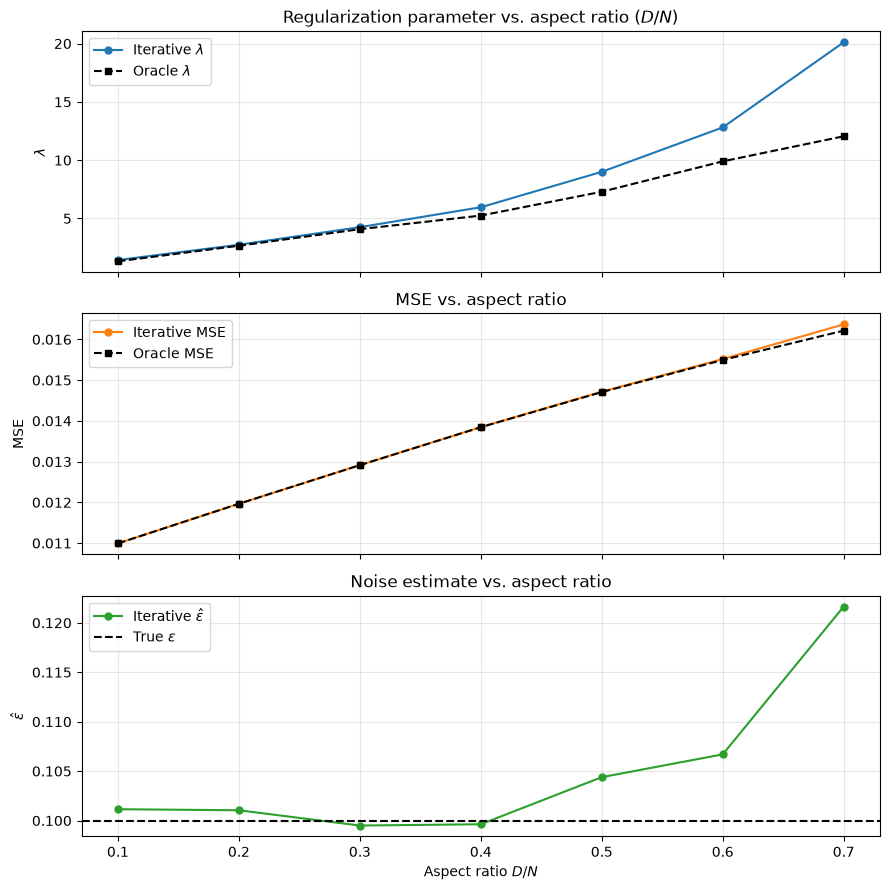

In [11]:
N_TRIAL = 1000
EPSILON = 0.1
LAMBDA_0 = 1
DELTA = 10 ** -4
P = 1 / 4

aspect_ratios = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

lam_stars, mse_stars, eps_finals = [], [], []
lam_oracles, mse_oracles = [], []

for ar in aspect_ratios:
    D_TRIAL = int(ar * N_TRIAL)

    rng = np.random.default_rng(seed=77)
    theta = rng.standard_normal(size=D_TRIAL)[:, np.newaxis]
    theta = theta / np.linalg.norm(theta)

    Sigma_bulk = bulk(D_TRIAL)

    (lam_star, mse_star), (lambdas, mses, noises), (lam_oracle, mse_oracle) = IterativeSampleOptReg(
        Sigma_bulk, LAMBDA_0, P, DELTA, theta_true=theta, epsilon_true=EPSILON,
        N_TRIAL=N_TRIAL, D_TRIAL=D_TRIAL, max_iter=100
    )

    lam_stars.append(lam_star)
    mse_stars.append(mse_star)
    eps_finals.append(noises[-1])
    lam_oracles.append(lam_oracle)
    mse_oracles.append(mse_oracle)

    print(f"aspect_ratio={ar:.1f} (D={D_TRIAL}): "
          f"lam={lam_star:.4g} (oracle {lam_oracle:.4g}), "
          f"mse={mse_star:.4g} (oracle {mse_oracle:.4g}), "
          f"eps_hat={noises[-1]:.4g} (true {EPSILON})")

lam_stars, mse_stars, eps_finals = map(np.array, (lam_stars, mse_stars, eps_finals))
lam_oracles, mse_oracles = map(np.array, (lam_oracles, mse_oracles))

marker_size = 5

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(aspect_ratios, lam_stars, marker="o", ms=marker_size, color="tab:blue", label=r"Iterative $\lambda$")
axes[0].plot(aspect_ratios, lam_oracles, marker="s", ms=marker_size, color="black", linestyle="--", label=r"Oracle $\lambda$")
axes[0].set_ylabel(r"$\lambda$")
axes[0].set_title(r"Regularization parameter vs. aspect ratio ($D/N$)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(aspect_ratios, mse_stars, marker="o", ms=marker_size, color="tab:orange", label="Iterative MSE")
axes[1].plot(aspect_ratios, mse_oracles, marker="s", ms=marker_size, color="black", linestyle="--", label="Oracle MSE")
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE vs. aspect ratio")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(aspect_ratios, eps_finals, marker="o", ms=marker_size, color="tab:green", label=r"Iterative $\hat{\epsilon}$")
axes[2].axhline(EPSILON, color="black", linestyle="--", linewidth=1.5, label=r"True $\epsilon$")
axes[2].set_ylabel(r"$\hat{\epsilon}$")
axes[2].set_xlabel(r"Aspect ratio $D/N$")
axes[2].set_title("Noise estimate vs. aspect ratio")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()